In [17]:
import sklearn
print(sklearn.__version__)

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

print("Random Forest import successful!")

1.6.1
Random Forest import successful!


In [18]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [5]:
model_data = pd.read_csv("../../data/processed/model_features.csv")

model_data.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AWAY_TEAM_ID,AWAY_LAST3_POINTS_SCORED,AWAY_LAST3_POINTS_ALLOWED,AWAY_LAST3_FG_PCT,AWAY_LAST3_FT_PCT,AWAY_LAST3_FG3_PCT,AWAY_LAST3_AST,AWAY_LAST3_REB,AWAY_LAST3_POINT_DIFFERENTIAL,AWAY_DAYS_SINCE_LAST_GAME
0,2003-10-31,20300020,Final,1610612748,1610612765,2003,1610612748,81.0,0.357,0.769,...,1610612765,95.666667,92.666667,0.425333,0.680667,0.354333,18.666667,39.000000,3.000000,2.0
1,2003-11-01,20300028,Final,1610612753,1610612765,2003,1610612753,85.0,0.390,0.762,...,1610612765,94.666667,86.333333,0.440000,0.747333,0.325333,17.333333,40.000000,8.333333,1.0
2,2003-11-01,20300030,Final,1610612740,1610612738,2003,1610612740,97.0,0.479,0.586,...,1610612738,93.333333,90.000000,0.480333,0.645333,0.252667,23.333333,41.666667,3.333333,1.0
3,2003-11-01,20300032,Final,1610612749,1610612741,2003,1610612749,98.0,0.448,0.519,...,1610612741,77.333333,85.000000,0.391333,0.690667,0.466000,17.666667,43.666667,-7.666667,1.0
4,2003-11-01,20300029,Final,1610612737,1610612754,2003,1610612737,99.0,0.468,0.677,...,1610612754,76.666667,79.333333,0.409667,0.664333,0.350000,16.333333,31.333333,-2.666667,1.0


In [6]:
feature_columns = [
    "HOME_LAST3_POINTS_SCORED",
    "HOME_LAST3_POINTS_ALLOWED",
    "HOME_LAST3_FG_PCT",
    "HOME_LAST3_FT_PCT",
    "HOME_LAST3_FG3_PCT",
    "HOME_LAST3_AST",
    "HOME_LAST3_REB",
    "HOME_LAST3_POINT_DIFFERENTIAL",
    "HOME_DAYS_SINCE_LAST_GAME",
    
    "AWAY_LAST3_POINTS_SCORED",
    "AWAY_LAST3_POINTS_ALLOWED",
    "AWAY_LAST3_FG_PCT",
    "AWAY_LAST3_FT_PCT",
    "AWAY_LAST3_FG3_PCT",
    "AWAY_LAST3_AST",
    "AWAY_LAST3_REB",
    "AWAY_LAST3_POINT_DIFFERENTIAL",
    "AWAY_DAYS_SINCE_LAST_GAME"
]

target_column = "TOTAL_POINTS"

print("Number of features:", len(feature_columns))
print("Target:", target_column)

Number of features: 18
Target: TOTAL_POINTS


In [7]:
train_data = model_data[
    model_data["SEASON"].isin([2012, 2013, 2014, 2015])
].copy()

validation_data = model_data[
    model_data["SEASON"] == 2016
].copy()

test_data = model_data[
    model_data["SEASON"] == 2017
].copy()

In [8]:
X_train = train_data[feature_columns]
y_train = train_data[target_column]

X_validation = validation_data[feature_columns]
y_validation = validation_data[target_column]

X_test = test_data[feature_columns]
y_test = test_data[target_column]

In [9]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (5681, 18) (5681,)
Validation: (1405, 18) (1405,)
Testing: (1382, 18) (1382,)


In [10]:
#MODEL 1:RANDOM FOREST REGRESSOR

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete!")

Random Forest training complete!


In [12]:
rf_train_pred = rf_model.predict(X_train)
rf_validation_pred = rf_model.predict(X_validation)
rf_test_pred = rf_model.predict(X_test)

print("Predictions generated!")

Predictions generated!


In [13]:
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_validation_mse = mean_squared_error(y_validation, rf_validation_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)

print("Random Forest MSE")
print("-------------------------")
print(f"Training MSE:   {rf_train_mse:.2f}")
print(f"Validation MSE: {rf_validation_mse:.2f}")
print(f"Test MSE:       {rf_test_mse:.2f}")

Random Forest MSE
-------------------------
Training MSE:   48.28
Validation MSE: 370.95
Test MSE:       378.28


In [14]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance


,Feature,Importance
0,HOME_LAST3_POINTS_SCORED,0.086872
9,AWAY_LAST3_POINTS_SCORED,0.086853
13,AWAY_LAST3_FG3_PCT,0.064248
1,HOME_LAST3_POINTS_ALLOWED,0.063292
4,HOME_LAST3_FG3_PCT,0.062340
3,HOME_LAST3_FT_PCT,0.062053
12,AWAY_LAST3_FT_PCT,0.061966
11,AWAY_LAST3_FG_PCT,0.060505
10,AWAY_LAST3_POINTS_ALLOWED,0.058980
15,AWAY_LAST3_REB,0.056548


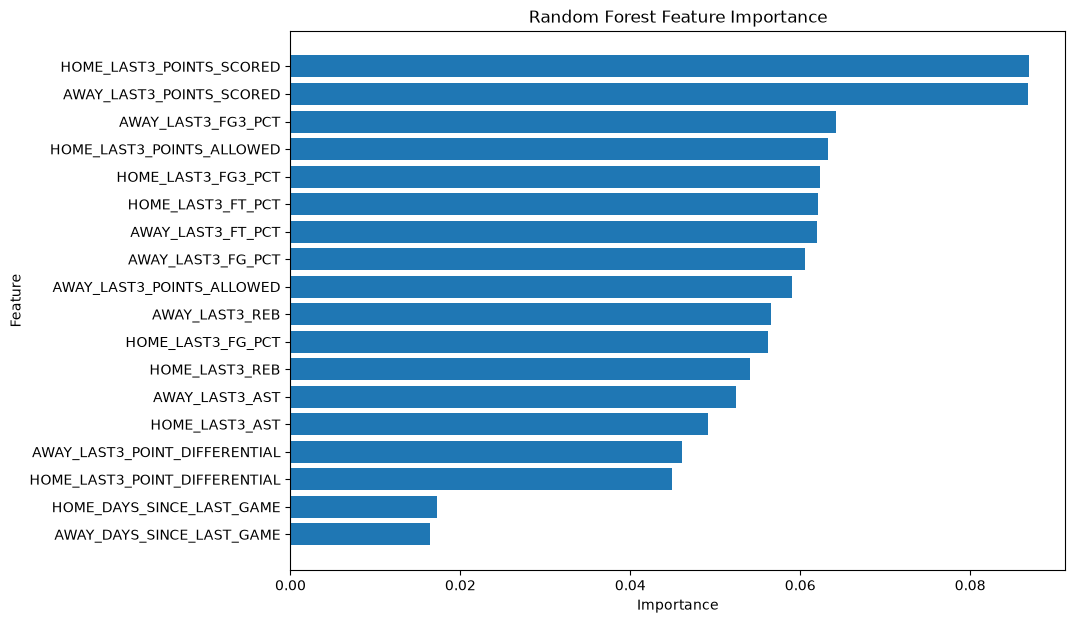

In [15]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [16]:
#MODEL 2: NEURAL NETWORK REGRESSOR


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")

Feature scaling complete!


In [21]:
scaler.fit_transform(X_train)

array([[-1.12868935,  0.10839091,  0.74462213, ...,  1.18631103,
         0.39773059,  8.77496355],
       [-2.00645583,  0.27960424, -1.29976041, ...,  0.70713061,
         2.75721157,  9.81633488],
       [-2.25724626, -1.3041191 , -0.66267376, ..., -0.25123022,
         1.00662891,  6.38593522],
       ...,
       [ 0.3342548 , -0.27683909,  0.16458801, ..., -0.25123022,
        -0.55367303, -0.04606416],
       [ 1.21202128, -0.23403576,  1.6384452 , ..., -0.89013744,
        -1.31479592, -0.04606416],
       [ 0.25065799,  1.00726092, -1.71814568, ..., -0.25123022,
         0.6641236 , -0.04606416]], shape=(5681, 18))

In [22]:
scaler.transform(X_validation)
scaler.transform(X_test)

array([[ 2.63316702,  2.97621427,  0.83020093, ...,  0.70713061,
         0.85440433, 10.24513484],
       [ 0.50144841,  0.57922758,  0.49739447, ..., -0.33109362,
        -0.32533616, 10.24513484],
       [-0.04193084,  2.07734426,  0.20262304, ..., -1.28945445,
        -0.47756074,  9.20376351],
       ...,
       [ 1.67180373, -0.36244576,  1.32465625, ...,  0.70713061,
         0.28356216, -0.04606416],
       [ 0.16706118,  1.05006425, -0.4154461 , ..., -0.65054723,
         1.4252465 , -0.04606416],
       [ 0.79403724,  2.3769676 , -0.60562122, ..., -1.04986424,
         1.38719035, -0.1073213 ]], shape=(1382, 18))

In [23]:
nn_model = MLPRegressor(
    hidden_layer_sizes=(500, 100, 20),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

print("Neural Network created!")

Neural Network created!


In [24]:
nn_model.fit(X_train_scaled, y_train)

print("Neural Network training complete!")

Neural Network training complete!


In [25]:
nn_train_pred = nn_model.predict(X_train_scaled)
nn_validation_pred = nn_model.predict(X_validation_scaled)
nn_test_pred = nn_model.predict(X_test_scaled)

print("Neural Network predictions generated!")

Neural Network predictions generated!


In [26]:
nn_train_mse = mean_squared_error(y_train, nn_train_pred)
nn_validation_mse = mean_squared_error(y_validation, nn_validation_pred)
nn_test_mse = mean_squared_error(y_test, nn_test_pred)

print("Neural Network MSE")
print("-------------------------")
print(f"Training MSE:   {nn_train_mse:.2f}")
print(f"Validation MSE: {nn_validation_mse:.2f}")
print(f"Test MSE:       {nn_test_mse:.2f}")

Neural Network MSE
-------------------------
Training MSE:   210.77
Validation MSE: 454.78
Test MSE:       472.53


In [27]:
model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    "Training MSE": [rf_train_mse, nn_train_mse],
    "Validation MSE": [rf_validation_mse, nn_validation_mse],
    "Test MSE": [rf_test_mse, nn_test_mse]
})

model_comparison

,Model,Training MSE,Validation MSE,Test MSE
0,Random Forest,48.283702,370.948943,378.276656
1,Neural Network,210.768726,454.779905,472.526307


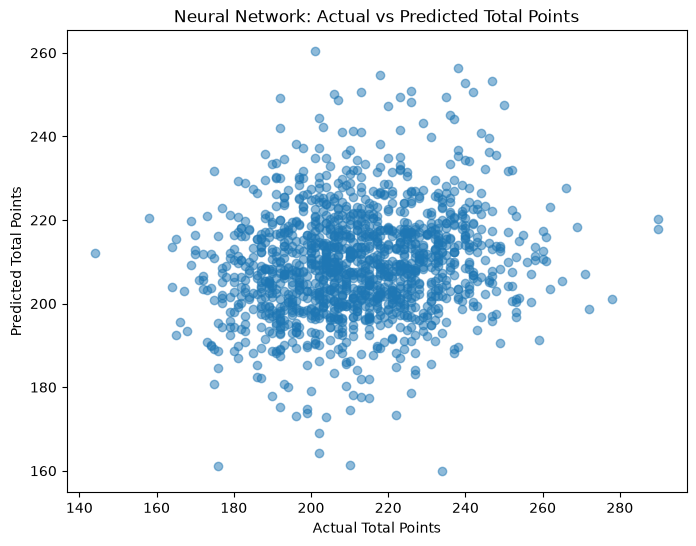

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, nn_test_pred, alpha=0.5)

plt.xlabel("Actual Total Points")
plt.ylabel("Predicted Total Points")
plt.title("Neural Network: Actual vs Predicted Total Points")

plt.show()